# ChoufMoney: Algerian Currency Recognition Using Deep Learning
This notebook demonstrates the evaluation and deployment pipeline for **ChoufMoney**, a Custom Convolutional Neural Network (CNN) designed to classify Algerian Dinar currency (banknotes and solid metallic coins).

## 🛠️ The Architecture & Strategy
Instead of relying on traditional flattening ML algorithms (like KNN, SVM, or Naive Bayes) which fail under shifting, lighting variations, and rotations, this system utilizes a **Convolutional Neural Network (CNN)**. 

### Key Design Pillars:
1. **Spatial Invariance:** Employs `Conv2D` and `MaxPooling2D` layers to extract structural features (edges, text fonts, stamped coin ridges) regardless of position in the frame.
2. **Data Augmentation:** Mitigates collection bias (e.g., matching the emblem side vs. numeric side of the 50/100/200 DA coins) by randomly applying real-time transformation matrices during training.
3. **Optimized Inference:** Keeps the compiled computational graph hot in volatile system memory to minimize desktop framework runtime latency.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

# Verify environment configuration
print(f"TensorFlow Version: {tf.__version__}")
print("Available Devices:", tf.config.list_physical_devices())

# Setup categorical definitions matching directory structures
CLASS_NAMES = ['100', '1000', '200', '2000', '50', '500']
MODEL_PATH = "algerian_money_model.keras"

# Load the compiled network model weights once
if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"\n🚀 Success: Loaded weights from '{MODEL_PATH}' into system memory.")
else:
    print(f"❌ Error: Model file '{MODEL_PATH}' not found in the current workspace.")

I0000 00:00:1782152614.465498   75001 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782152615.419301   75001 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782152618.735052   75001 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow Version: 2.21.0
Available Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1782152620.223511   75001 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1782152620.524171   75001 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1782152620.593431   75001 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1782152620.629542   75001 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1782152620.806764   75001 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1782152620.817991   75001 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.



🚀 Success: Loaded weights from 'algerian_money_model.keras' into system memory.


## 📊 Interactive Inference & Feature Extraction
The function below abstracts the processing architecture:
1. It maps a local system image array to the standard $224 \times 224 \times 3$ matrix expected by the input tensor.
2. It executes a forward pass (`model.predict()`).
3. It passes the raw output logits through a Softmax activation layer to compute clean classification probabilities.

In [3]:
def predict_and_plot_currency(img_path):
    """
    Loads a test image, runs a forward pass through the CNN model, 
    and plots the image alongside a probability bar chart.
    """
    if not os.path.exists(img_path):
        print(f"File {img_path} not found.")
        return

    # 1. Preprocess image to match input tensor requirements
    img = image.load_img(img_path, target_size=(224, 224))
    img_tensor = image.img_to_array(img)
    img_tensor = np.expand_dims(img_tensor, axis=0)  # Expand dimensions to create batch scale

    # 2. Execute computational prediction pass
    predictions = model.predict(img_tensor, verbose=0)
    probabilities = tf.nn.softmax(predictions[0]).numpy()

    predicted_idx = np.argmax(probabilities)
    predicted_label = CLASS_NAMES[predicted_idx]
    confidence_score = probabilities[predicted_idx] * 100

    # 3. Visualization Layout (1 row, 2 columns)
    plt.figure(figsize=(12, 5))

    # Left plot: Display the original source image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_label} DA\nConfidence: {confidence_score:.2f}%", 
              fontsize=14, fontweight='bold', color='green' if confidence_score > 75 else 'orange')

    # Right plot: Display probability distribution across classes
    plt.subplot(1, 2, 2)
    bars = plt.bar(CLASS_NAMES, probabilities * 100, color='gray')
    bars[predicted_idx].set_color('mediumseagreen') # Highlight the winning class
    plt.ylabel('Confidence Percentage (%)')
    plt.xlabel('Currency Denomination (DA)')
    plt.title('Network Probability Distribution')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

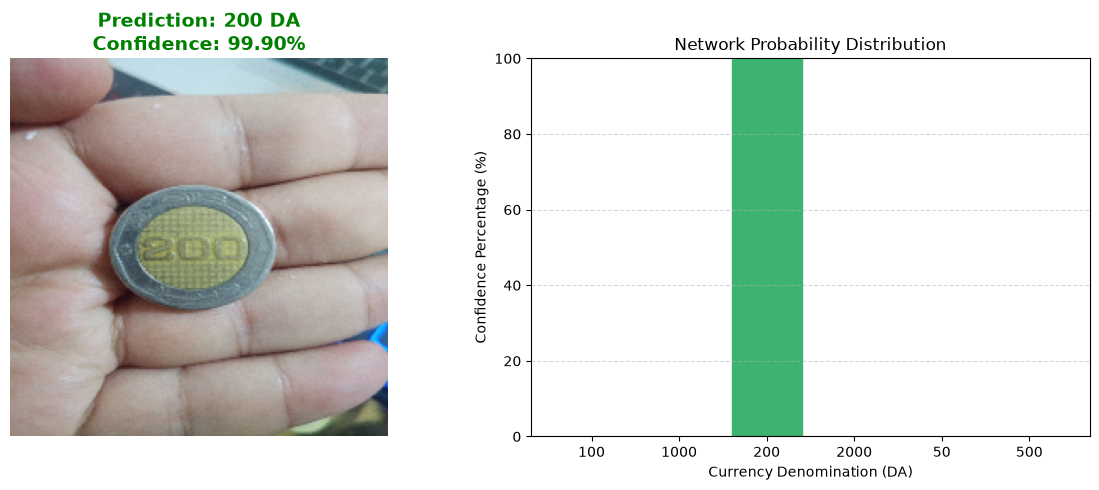

In [12]:
# Place any of your local images here to generate the fancy results charts!
# It will instantly display the picture alongside a clean distribution bar chart.

predict_and_plot_currency("rtest8.jpg")
